In [85]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
import joblib
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

dataset = pd.read_csv("../data/imdb_cleaned.csv")

In [86]:
tfidf = TfidfVectorizer(max_features=5000) #initalize the vectorizer 
X = tfidf.fit_transform(dataset['cleaned_review']) #use the cleaned review as the features
y = dataset['sentiment'].map({'positive': 1, 'negative': 0}) #labels

#split the dataset into training and testing with an 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=485)

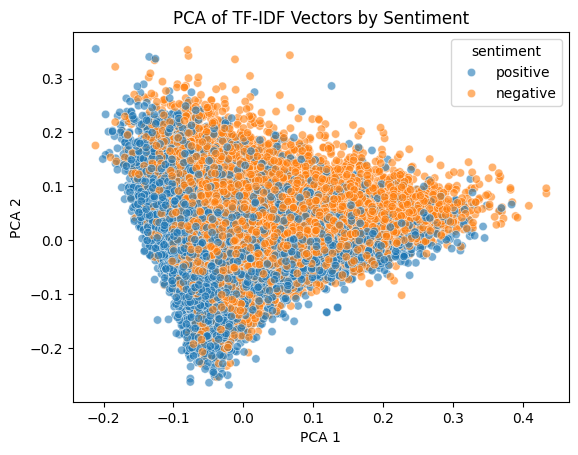

In [87]:
pca = PCA(n_components=2) 
X_pca = pca.fit_transform(X.toarray()) 

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=dataset['sentiment'], alpha=0.6)
plt.title("PCA of TF-IDF Vectors by Sentiment")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

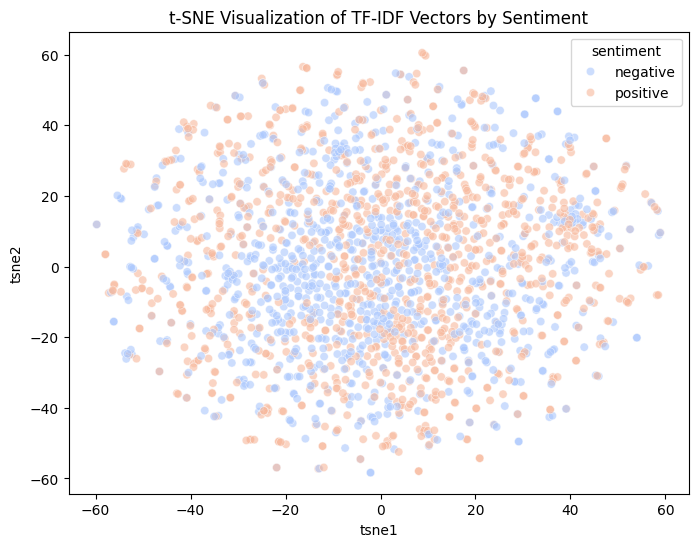

In [88]:
X_dense = X.toarray()  # Convert sparse matrix to dense for t-SNE
sample_size = 2000
indices = np.random.choice(len(X_dense), size=sample_size, replace=False)

X_sample = X_dense[indices]
y_sample = dataset.iloc[indices]['sentiment']  # or ['label']

# Run t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=4850)
X_tsne = tsne.fit_transform(X_sample)

tsne_df = pd.DataFrame({
    'tsne1': X_tsne[:, 0],
    'tsne2': X_tsne[:, 1],
    'sentiment': y_sample.values
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=tsne_df, x='tsne1', y='tsne2', hue='sentiment', alpha=0.6, palette='coolwarm')
plt.title("t-SNE Visualization of TF-IDF Vectors by Sentiment")
plt.show()

### Train Basic Models 

Naibe Bayes


In [89]:
nb = MultinomialNB() 
nb.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [90]:
parameters_nb = {'alpha': [0.1, 0.5, 1.0, 2.0, 5.0]} #parameter tuning for Naive Bayes
grid_search_nb = GridSearchCV(nb, parameters_nb, cv=5, scoring='accuracy')
grid_search_nb.fit(X_train, y_train)

,estimator,MultinomialNB()
,param_grid,"{'alpha': [0.1, 0.5, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,5.0


In [91]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [92]:
paramters_lr = {'C': [0.01, 0.1, 1, 10, 100]} #parameter tuning for Logistic Regression
grid_search_lr = GridSearchCV(lr, paramters_lr, cv=5, scoring='accuracy')
grid_search_lr.fit(X_train, y_train)

,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [0.01, 0.1, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


Naive Bayes:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      5006
           1       0.85      0.86      0.86      4994

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



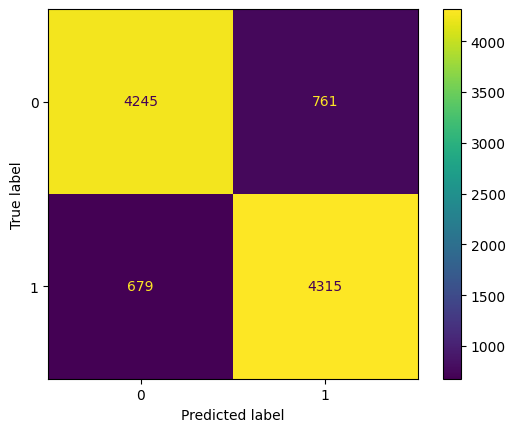

In [93]:
nb_y_pred = nb.predict(X_test)
print("Naive Bayes:")
print(classification_report(y_test, nb_y_pred))

conMatrix = confusion_matrix(y_test, nb_y_pred)
dispMatrix = ConfusionMatrixDisplay(confusion_matrix=conMatrix)
dispMatrix.plot()

Grid Search Naive Bayes:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      5006
           1       0.86      0.86      0.86      4994

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



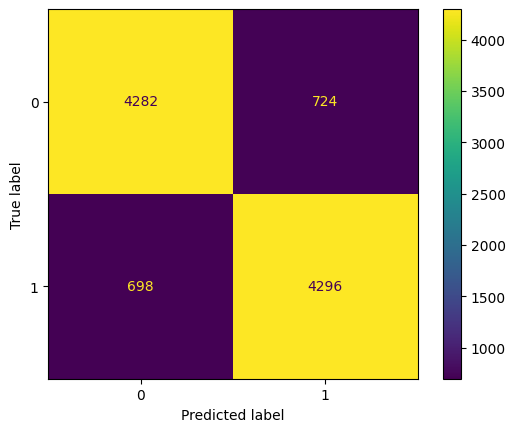

In [94]:
gs_nb_y_pred = grid_search_nb.predict(X_test)
print("Grid Search Naive Bayes:")
print(classification_report(y_test, gs_nb_y_pred))
conMatrix = confusion_matrix(y_test, gs_nb_y_pred)
dispMatrix = ConfusionMatrixDisplay(confusion_matrix=conMatrix)
dispMatrix.plot()

Logisitic Regression:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      5006
           1       0.88      0.91      0.89      4994

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



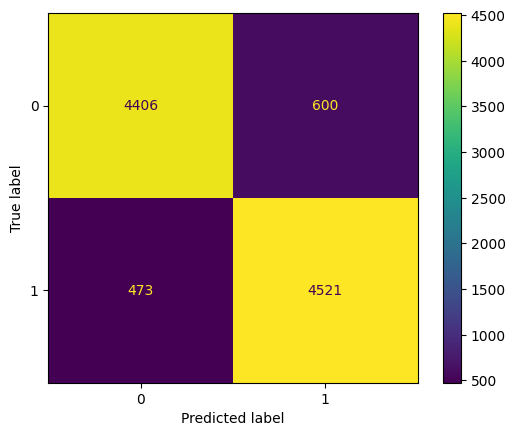

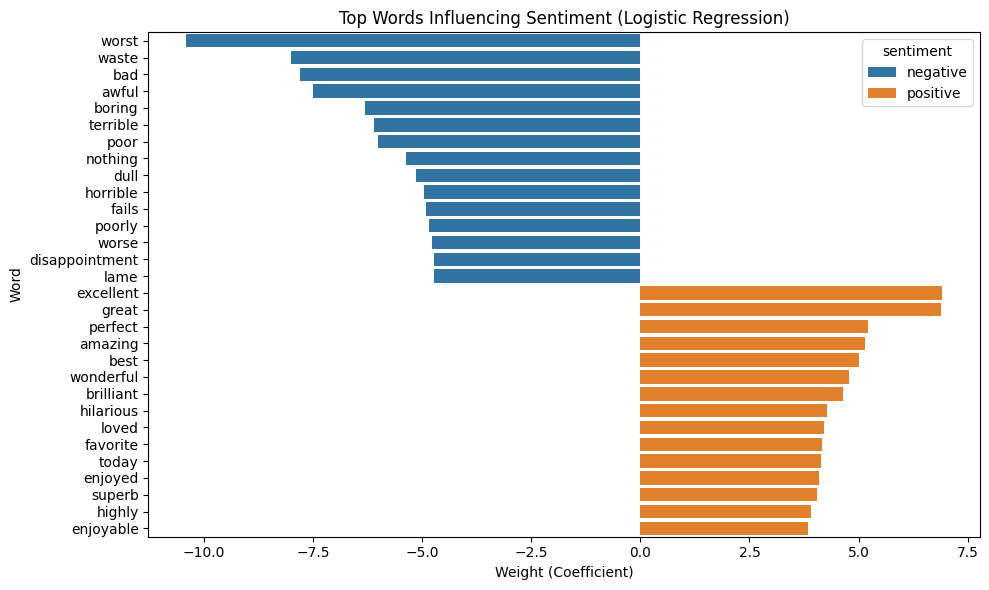

In [95]:
lr_y_pred = lr.predict(X_test)
print("Logisitic Regression:")
print(classification_report(y_test, lr_y_pred))

conMatrix = confusion_matrix(y_test, lr_y_pred)
dispMatrix = ConfusionMatrixDisplay(confusion_matrix=conMatrix)
dispMatrix.plot()

coef = lr.coef_[0]
feature_names = tfidf.get_feature_names_out()

weights_df = pd.DataFrame({'feature': feature_names, 'weight': coef})

top_positive = weights_df.sort_values(by='weight', ascending=False).head(15)
top_negative = weights_df.sort_values(by='weight').head(15)

top_words = pd.concat([top_negative, top_positive])
top_words['sentiment'] = ['negative']*15 + ['positive']*15

plt.figure(figsize=(10,6))
sns.barplot(data=top_words, x='weight', y='feature', hue='sentiment', dodge=False)
plt.title("Top Words Influencing Sentiment (Logistic Regression)")
plt.xlabel("Weight (Coefficient)")
plt.ylabel("Word")
plt.tight_layout()
plt.show()


Grid Search Logistic Regression:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      5006
           1       0.88      0.91      0.89      4994

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



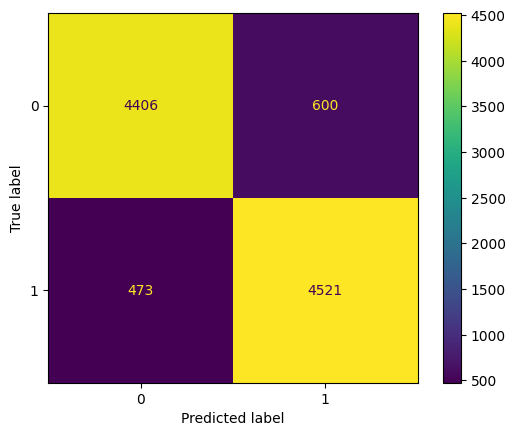

In [96]:
gs_lr_y_pred = grid_search_lr.predict(X_test)
print("Grid Search Logistic Regression:")
print(classification_report(y_test, gs_lr_y_pred))
conMatrix = confusion_matrix(y_test, gs_lr_y_pred)
dispMatrix = ConfusionMatrixDisplay(confusion_matrix=conMatrix)
dispMatrix.plot()

Additional Models


In [97]:
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [98]:
svm = LinearSVC()
svm.fit(X_train, y_train)


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [99]:
rf = RandomForestClassifier(n_estimators=100, random_state=4850)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [100]:
xbg = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xbg.fit(X_train, y_train)

d:\School\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:11:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


Support Vector Machine:
              precision    recall  f1-score   support

           0       0.89      0.88      0.88      5006
           1       0.88      0.89      0.88      4994

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



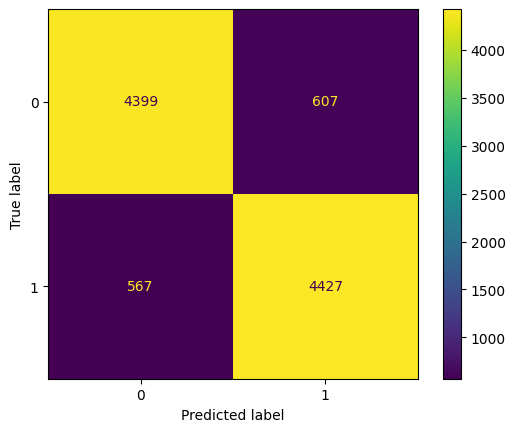

In [101]:
svm_y_pred = svm.predict(X_test)
print("Support Vector Machine:")
print(classification_report(y_test, svm_y_pred))

conMatrix = confusion_matrix(y_test, svm_y_pred)
dispMatrix = ConfusionMatrixDisplay(confusion_matrix=conMatrix)
dispMatrix.plot()

Save The Models


Random Forest:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      5006
           1       0.86      0.84      0.85      4994

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



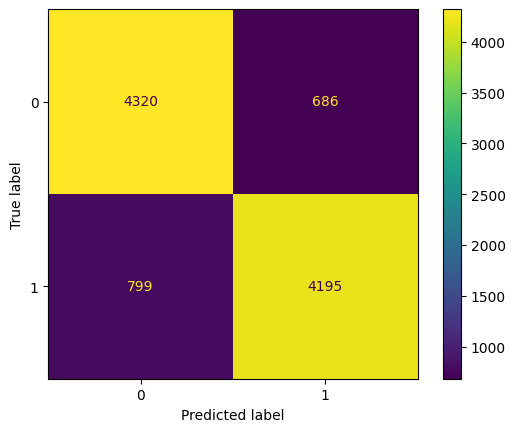

In [102]:
rf_y_pred = rf.predict(X_test)
print("Random Forest:")
print(classification_report(y_test, rf_y_pred))

conMatrix = confusion_matrix(y_test, rf_y_pred)
dispMatrix = ConfusionMatrixDisplay(confusion_matrix=conMatrix)
dispMatrix.plot()

XGBoost:
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      5006
           1       0.84      0.88      0.86      4994

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



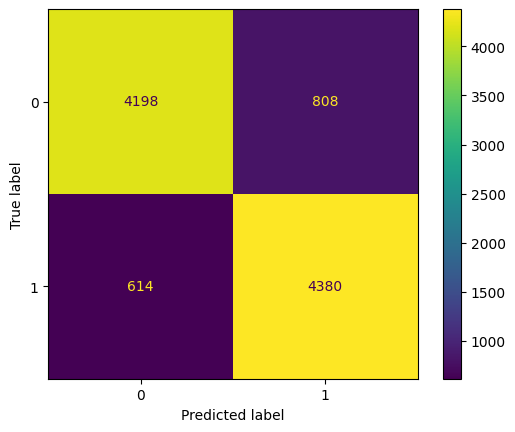

In [103]:
xbg_y_pred = xbg.predict(X_test)
print("XGBoost:")
print(classification_report(y_test, xbg_y_pred))

conMatrix = confusion_matrix(y_test, xbg_y_pred)
dispMatrix = ConfusionMatrixDisplay(confusion_matrix=conMatrix)
dispMatrix.plot()

In [ ]:
joblib.dump(tfidf, '../models/tfidf_vectorizer.joblib') 
joblib.dump(nb, '../models/naive_bayes_model.pkl') 
joblib.dump(lr, '../models/logistic_regression_model.joblib') 
joblib.dump(svm, '../models/svm_model.pkl')
joblib.dump(rf, '../models/random_forest_model.pkl')
joblib.dump(xbg, '../models/xgboost_model.pkl')

['../models/xgboost_model.pkl']